# Funnel Analysis: Understanding the Order Journey

## Objective

The goal of this analysis is to understand how customers progress through the Olist order fulfillment process and identify where orders drop off before reaching successful delivery.

By analyzing each stage of the order lifecycle, we can uncover operational bottlenecks that negatively impact customer experience and business performance.

## Business Questions

This analysis aims to answer the following questions:

1. How many orders successfully move through each stage of the order process?

2. What percentage of orders reach the final delivery stage?

3. Which stage has the highest drop-off rate?

4. Are there opportunities to improve operational efficiency and customer satisfaction?

5. Which part of the fulfillment process should the business prioritize for improvement?

## Why Are We Performing Funnel Analysis?

Funnel analysis helps businesses understand how customers move through a process from start to finish.

In e-commerce, the customer journey does not end when an order is placed. Orders must be approved, shipped, and delivered successfully.

A small decline at each stage can result in significant revenue loss, increased support costs, and lower customer satisfaction.

Understanding where customers drop off allows the business to:

- Identify operational bottlenecks
- Improve logistics performance
- Reduce order cancellations
- Increase delivery success rates
- Enhance customer experience
- Improve retention and future purchases

## Order Fulfillment Funnel

The Olist order process consists of the following stages:

**Purchase → Approval → Shipped → Delivered**

The corresponding dataset columns are:

| Funnel Stage | Dataset Column |
|:-------------|:----------------|
| Purchase | `order_purchase_timestamp` |
| Approved | `order_approved_at` |
| Shipped | `order_delivered_carrier_date` |
| Delivered | `order_delivered_customer_date` |

An order is considered to have reached a stage if the corresponding timestamp is not null.

## Methodology

To build the funnel:

1. Count the number of orders with a valid timestamp for each stage.
2. Calculate the conversion rate between consecutive stages.
3. Calculate the overall conversion rate from purchase to delivery.
4. Visualize the order flow to identify drop-offs.

This approach provides a clear view of the order fulfillment process and highlights areas for operational improvement.

In [ ]:
# import llibabries 
import pandas as pd 
import numpy as np
from pathlib import Path

In [29]:
# Load dataset from CSV file into a pandas DataFrame.
DATA_DIR = Path("../data")

orders_df = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
customers_df = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
reviews_df = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
products_df=pd.read_csv(DATA_DIR/"olist_products_dataset.csv")
order_items_df = pd.read_csv(DATA_DIR /"olist_order_items_dataset.csv")
product_category_name_translation_df=pd.read_csv(DATA_DIR/"product_category_name_translation.csv")




In [ ]:
#verify all columns need it 
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


## Data Validation Summary

The `orders_df` dataset contains all required fields to analyze the order fulfillment funnel.

### Dataset Overview

- Total orders: **99,441**
- Each row represents a unique order.
- Timestamp columns currently have the `object` data type and must be converted to `datetime`.

### Data Completeness

| Funnel Stage | Column | Non-Null Records |
|:--------------|:-------|------------------:|
| Purchase | `order_purchase_timestamp` | 99,441 |
| Approval | `order_approved_at` | 99,281 |
| Shipped | `order_delivered_carrier_date` | 97,658 |
| Delivered | `order_delivered_customer_date` | 96,476 |

The decreasing number of non-null values indicates that not all orders successfully progress through every stage of the fulfillment process.

This validates the need for funnel analysis to identify where order drop-offs occur.

In [5]:
# Convert timestamp columns from object to datetime.
# Datetime format is required for funnel calculations and duration analysis.

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders_df[col] = pd.to_datetime(
        orders_df[col],
        errors="coerce"
    )

# Verify the conversion

orders_df[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [6]:
orders_df[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

## Building the Order Fulfillment Funnel

The order lifecycle consists of four key stages:

**Purchase → Approval → Shipped → Delivered**

An order is considered to have reached a stage if the corresponding timestamp is available.

For each stage, we will calculate:

1. The number of orders that reached the stage
2. The conversion rate from the previous stage
3. The overall conversion rate from purchase to delivery

This analysis helps identify where orders drop off and highlights opportunities to improve operational efficiency.

## How the Funnel Works

The first step is to count how many orders reached each stage of the fulfillment process.

- **Purchase:** Total number of orders placed.
- **Approved:** Number of orders with approved payments.
- **Shipped:** Number of orders handed to the carrier.
- **Delivered:** Number of orders successfully delivered to customers.

Next, we calculate the conversion rate between stages to understand how efficiently orders move through the process.

For example:

- Purchase → Approved:
  - What percentage of purchased orders were approved?

- Approved → Shipped:
  - What percentage of approved orders were shipped?

- Shipped → Delivered:
  - What percentage of shipped orders were delivered?

The Purchase stage is set to **100%** because it is the starting point of the funnel.

The total number of purchased orders becomes our baseline for the entire analysis.

We then compare every stage against this baseline to calculate the overall conversion rate from purchase to delivery.

This helps identify where orders are being lost and which stage offers the biggest opportunity for improvement.

In [7]:
# Count the number of orders that reached each stage.
# Non-null timestamps indicate successful progression.

funnel_df = pd.DataFrame({
    "stage": [
        "Purchase",
        "Approved",
        "Shipped",
        "Delivered"
    ],
    "order_count": [
        orders_df["order_purchase_timestamp"].notna().sum(),
        orders_df["order_approved_at"].notna().sum(),
        orders_df["order_delivered_carrier_date"].notna().sum(),
        orders_df["order_delivered_customer_date"].notna().sum()
    ]
})

# Calculate the conversion rate between consecutive stages.

funnel_df["conversion_from_previous_pct"] = (
    funnel_df["order_count"]
    .div(funnel_df["order_count"].shift(1))
    .mul(100)
    .round(2)
)

# The first stage represents all orders.

funnel_df.loc[0, "conversion_from_previous_pct"] = 100.0

# Calculate the cumulative conversion rate from purchase.

total_orders = funnel_df.loc[0, "order_count"]

funnel_df["conversion_from_start_pct"] = (
    funnel_df["order_count"]
    .div(total_orders)
    .mul(100)
    .round(2)
)

funnel_df

,stage,order_count,conversion_from_previous_pct,conversion_from_start_pct
0,Purchase,99441,100.00,100.00
1,Approved,99281,99.84,99.84
2,Shipped,97658,98.37,98.21
3,Delivered,96476,98.79,97.02


## Funnel Analysis Results

The funnel analysis shows that most orders successfully progress through the fulfillment process.

### Funnel Summary

| Stage | Orders | Conversion from Previous Stage |
|:-------|-------:|-------------------------------:|
| Purchase | 99,441 | 100.00% |
| Approved | 99,281 | 99.84% |
| Shipped | 97,658 | 98.37% |
| Delivered | 96,476 | 98.79% |

### Key Findings

- Out of 99,441 purchased orders, 96,476 were successfully delivered.
- The overall conversion rate from purchase to delivery is **97.02%**.
- Only **2.98%** of orders failed to reach the final delivery stage.

### Largest Drop-Off

The largest drop-off occurs between the **Approved** and **Shipped** stages.

- Approved orders: 99,281
- Shipped orders: 97,658
- Orders lost: 1,623

This represents a conversion rate of **98.37%**, the lowest among all funnel stages.

### Business Interpretation

The results suggest that payment approval is not a significant issue, as nearly all purchases are approved.

The primary operational challenge appears to occur after payment approval and before shipment.

Potential reasons may include:

- Inventory shortages
- Supplier delays
- Warehouse processing inefficiencies
- Order cancellations after approval
- Logistics capacity constraints

Once orders are shipped, the delivery process performs efficiently, with 98.79% of shipped orders reaching customers successfully.

### Business Impact

Improving the transition from approval to shipment could:

- Increase delivery success rates
- Reduce customer complaints
- Improve customer satisfaction
- Increase repeat purchases
- Reduce operational costs associated with cancellations and support requests

## Recommendation

Focus operational improvements on the period between payment approval and shipment.

Recommended actions include:

- Monitor inventory availability in real time
- Optimize warehouse picking and packing processes
- Improve supplier coordination
- Track order processing delays using service-level agreements (SLAs)
- Create alerts for orders that remain unshipped beyond a predefined threshold

Reducing delays at this stage is likely to have the greatest impact on overall funnel performance.

## Why Analyze Stage Durations?

The funnel analysis showed us where orders drop off.

However, conversion rates alone do not explain whether customers are experiencing delays.

By measuring the time between milestones, we can identify bottlenecks in the order fulfillment process.

This analysis helps answer questions such as:

- How quickly are payments approved?
- How long does it take to ship an order after approval?
- How long does delivery take after shipment?
- Which stage contributes the most to the total fulfillment time?

Reducing delays can improve customer satisfaction, increase repeat purchases, and lower support costs.

In [8]:
# Create a copy to preserve the original dataset.

delivery_metrics_df = orders_df.copy()

# Calculate the time spent in each stage of the fulfillment process.

delivery_metrics_df["approval_days"] = (
    delivery_metrics_df["order_approved_at"]
    - delivery_metrics_df["order_purchase_timestamp"]
).dt.days

delivery_metrics_df["shipping_days"] = (
    delivery_metrics_df["order_delivered_carrier_date"]
    - delivery_metrics_df["order_approved_at"]
).dt.days

delivery_metrics_df["delivery_days"] = (
    delivery_metrics_df["order_delivered_customer_date"]
    - delivery_metrics_df["order_delivered_carrier_date"]
).dt.days

delivery_metrics_df["total_fulfillment_days"] = (
    delivery_metrics_df["order_delivered_customer_date"]
    - delivery_metrics_df["order_purchase_timestamp"]
).dt.days

# Review the new metrics.

delivery_metrics_df[
    [
        "approval_days",
        "shipping_days",
        "delivery_days",
        "total_fulfillment_days"
    ]
].head()

,approval_days,shipping_days,delivery_days,total_fulfillment_days
0,0.0,2.0,6.0,8.0
1,1.0,0.0,12.0,13.0
2,0.0,0.0,9.0,9.0
3,0.0,3.0,9.0,13.0
4,0.0,0.0,1.0,2.0


In [9]:
# Generate summary statistics for the duration metrics.

duration_summary_df = (
    delivery_metrics_df[
        [
            "approval_days",
            "shipping_days",
            "delivery_days",
            "total_fulfillment_days"
        ]
    ]
    .describe()
    .round(2)
)

duration_summary_df

,approval_days,shipping_days,delivery_days,total_fulfillment_days
count,99281.00,97644.00,96475.00,96476.00
mean,0.27,2.30,8.88,12.09
std,0.99,3.56,8.75,9.55
min,0.00,-172.00,-17.00,0.00
25%,0.00,0.00,4.00,6.00
50%,0.00,1.00,7.00,10.00
75%,0.00,3.00,12.00,15.00
max,187.00,125.00,205.00,209.00


## Delivery Time Analysis Results

The average order takes **12.09 days** to move from purchase to delivery.

### Stage Duration Summary

| Metric | Average Days | Median Days |
|:--------|--------------:|-------------:|
| Approval Time | 0.27 | 0 |
| Shipping Time | 2.30 | 1 |
| Delivery Time | 8.88 | 7 |
| Total Fulfillment Time | 12.09 | 10 |

### Key Findings

- Payment approval is highly efficient, taking less than one day on average.
- Orders are typically shipped within 2 to 3 days after approval.
- The delivery stage is the longest part of the fulfillment process, accounting for approximately 73% of the total fulfillment time.

```text
8.88 delivery days ÷ 12.09 total days ≈ 73%


---

##  Data Quality Observation


Some duration metrics contain negative values:

| Metric | Minimum Value |
|:--------|---------------:|
| Shipping Time | -172 days |
| Delivery Time | -17 days |

Negative durations are not logically possible and likely indicate:

- Data entry errors
- Timestamp inconsistencies
- Time zone differences
- Missing or incorrectly updated records

Examples include:

- Carrier pickup date occurring before approval date
- Customer delivery date occurring before carrier pickup date

These records should be excluded from duration analysis to avoid skewing results.

In [10]:
# Keep only records with valid duration values.

valid_delivery_metrics_df = delivery_metrics_df[
    (delivery_metrics_df["approval_days"] >= 0) &
    (delivery_metrics_df["shipping_days"] >= 0) &
    (delivery_metrics_df["delivery_days"] >= 0) &
    (delivery_metrics_df["total_fulfillment_days"] >= 0)
].copy()

# Compare record counts before and after cleaning.

print(f"Original records: {len(delivery_metrics_df):,}")
print(f"Valid records: {len(valid_delivery_metrics_df):,}")
print(f"Removed records: {len(delivery_metrics_df) - len(valid_delivery_metrics_df):,}")

Original records: 99,441
Valid records: 95,088
Removed records: 4,353


## Recommendations

The delivery stage represents the largest opportunity for improvement.

Recommended actions include:

- Optimize carrier selection and routing
- Monitor delivery performance by region
- Identify carriers with consistently longer delivery times
- Investigate causes of delayed deliveries
- Create alerts for orders exceeding expected delivery windows

Reducing delivery time by even one day could significantly improve customer satisfaction and increase repeat purchases.


## Business Insight

Even after removing invalid records, more than **95%** of orders remain available for analysis.

This indicates that the dataset maintains a high level of quality and provides a strong foundation for evaluating the order fulfillment process.



In [11]:
# Re-run the summary statistics using the cleaned dataset:
duration_summary_df = (
    valid_delivery_metrics_df[
        [
            "approval_days",
            "shipping_days",
            "delivery_days",
            "total_fulfillment_days"
        ]
    ]
    .describe()
    .round(2)
)

duration_summary_df

,approval_days,shipping_days,delivery_days,total_fulfillment_days
count,95088.00,95088.00,95088.00,95088.00
mean,0.24,2.35,8.91,12.15
std,0.67,3.49,8.76,9.58
min,0.00,0.00,0.00,0.00
25%,0.00,0.00,4.00,6.00
50%,0.00,1.00,7.00,10.00
75%,0.00,3.00,12.00,15.00
max,30.00,125.00,205.00,209.00


## Delivery Time Analysis Results

After removing invalid records, the analysis was performed on **95,088 orders** with valid fulfillment timelines.

### Stage Duration Summary

| Metric | Average Days | Median Days |
|:--------|--------------:|-------------:|
| Approval Time | 0.24 | 0 |
| Shipping Time | 2.35 | 1 |
| Delivery Time | 8.91 | 7 |
| Total Fulfillment Time | 12.15 | 10 |

### Key Findings

- Payment approval is highly efficient, taking less than one day on average.
- Orders are typically shipped within 2 to 3 days after approval.
- The delivery stage is the longest part of the fulfillment process.

Delivery accounts for approximately **73%** of the total fulfillment time.

```text
8.91 ÷ 12.15 × 100 ≈ 73%


---

##  Business Interpretation



The order approval process performs efficiently and is unlikely to be a major source of customer dissatisfaction.

The largest opportunity for operational improvement lies in reducing delivery time.

Potential improvement areas include:

- Carrier performance management
- Route optimization
- Regional warehouse allocation
- Inventory positioning
- Delivery partner service-level agreements (SLAs)

Reducing delivery time by even one day could significantly improve customer satisfaction and increase repeat purchases.

## Outlier Analysis

Although the median delivery time is 7 days, some orders experience significantly longer delays.

Maximum observed durations include:

- Approval Time: 30 days
- Shipping Time: 125 days
- Delivery Time: 205 days
- Total Fulfillment Time: 209 days

The large difference between median and maximum values indicates the presence of extreme outliers.

These outliers should be investigated further to identify:

- Geographic challenges
- Carrier issues
- Inventory shortages
- Seasonal demand spikes
- Operational inefficiencies

## Business Question

Are orders delivered earlier, on time, or later than the promised delivery date?

Meeting delivery expectations is a critical driver of customer satisfaction and repeat purchases.

## Why Analyze Delivery Performance?

Customers care not only about how fast orders arrive but also whether they arrive when promised.

Late deliveries can lead to:

- Lower customer satisfaction
- Negative reviews
- Increased support requests
- Higher cancellation and return rates
- Reduced customer loyalty

Comparing actual delivery dates with estimated delivery dates helps evaluate the reliability of the fulfillment process.

In [12]:
# Calculate delivery delay in days.
# Negative values indicate early deliveries.
# Positive values indicate late deliveries.

valid_delivery_metrics_df["delivery_delay_days"] = (
    valid_delivery_metrics_df["order_delivered_customer_date"]
    - valid_delivery_metrics_df["order_estimated_delivery_date"]
).dt.days

# Review the first few records.

valid_delivery_metrics_df[
    [
        "order_estimated_delivery_date",
        "order_delivered_customer_date",
        "delivery_delay_days"
    ]
].head()

,order_estimated_delivery_date,order_delivered_customer_date,delivery_delay_days
0,2017-10-18,2017-10-10 21:25:13,-8
1,2018-08-13,2018-08-07 15:27:45,-6
2,2018-09-04,2018-08-17 18:06:29,-18
3,2017-12-15,2017-12-02 00:28:42,-13
4,2018-02-26,2018-02-16 18:17:02,-10


In [13]:
# Create delivery status categories.

valid_delivery_metrics_df["delivery_status"] = np.where(
    valid_delivery_metrics_df["delivery_delay_days"] > 0,
    "Late",
    "On Time / Early"
)

# Count orders by delivery status.

delivery_performance_df = (
    valid_delivery_metrics_df["delivery_status"]
    .value_counts()
    .reset_index()
)

delivery_performance_df.columns = [
    "delivery_status",
    "order_count"
]

delivery_performance_df["percentage"] = (
    delivery_performance_df["order_count"]
    / delivery_performance_df["order_count"].sum()
    * 100
).round(2)

delivery_performance_df

,delivery_status,order_count,percentage
0,On Time / Early,88578,93.15
1,Late,6510,6.85


## Delivery Performance Results

The analysis shows that Olist delivers orders reliably and consistently meets customer expectations.

### Delivery Performance Summary

| Delivery Status | Orders | Percentage |
|:-----------------|-------:|------------:|
| On Time / Early | 88,578 | 93.15% |
| Late | 6,510 | 6.85% |

### Key Findings

- More than **93%** of orders are delivered on or before the promised delivery date.
- Only **6.85%** of orders arrive later than expected.
- The estimated delivery process appears to be accurate and reliable.

These results indicate strong operational performance and effective logistics planning.

## Business Interpretation

Meeting delivery expectations is a major contributor to customer satisfaction and loyalty.

A delivery success rate above 90% suggests that:

- Delivery estimates are realistic.
- Carrier performance is well managed.
- Inventory and warehouse operations are functioning efficiently.
- Customers are likely to trust the promised delivery dates.

Although late deliveries affect a relatively small percentage of orders, even minor delays can have a disproportionate impact on customer reviews and repeat purchases.

## Recommendations

While overall delivery performance is strong, the business should investigate the 6.85% of late deliveries.

Recommended actions include:

- Identify regions with higher late-delivery rates.
- Evaluate carrier performance by delivery time.
- Analyze seasonal trends and demand spikes.
- Monitor warehouse processing times.
- Create alerts for orders at risk of missing their estimated delivery date.

Reducing late deliveries even further can improve customer satisfaction and strengthen customer retention.

In [14]:
# Generate summary statistics for delivery delays.

valid_delivery_metrics_df["delivery_delay_days"].describe().round(2)

count    95088.00
mean       -11.83
std         10.20
min       -147.00
25%        -17.00
50%        -12.00
75%         -7.00
max        188.00
Name: delivery_delay_days, dtype: float64


---

## Markdown Cell — Business Interpretation

```markdown id="x6n2rt"
## Business Interpretation

Providing conservative delivery estimates helps reduce customer frustration and build trust.

Delivering earlier than promised can lead to:

- Higher customer satisfaction
- Better review scores
- Increased customer loyalty
- More repeat purchases

However, excessively conservative estimates may create unintended consequences.

For example:

- Customers may delay purchases if estimated delivery times appear too long.
- Longer quoted delivery windows may reduce competitiveness.

The business should evaluate whether delivery estimates can be optimized while maintaining a high on-time delivery rate.

## Recommendations

The current delivery process performs well, with more than 93% of orders arriving on time or early.

Recommended actions include:

- Investigate the causes of late deliveries for the remaining 6.85% of orders.
- Analyze late deliveries by region, carrier, and product category.
- Reassess estimated delivery windows to determine whether they can be shortened without increasing late deliveries.
- Monitor customer review scores to measure the impact of delivery performance.

A balanced delivery promise should maximize both customer satisfaction and conversion rates.

## Business Question

How does delivery performance affect customer satisfaction?

Specifically, do customers who receive late orders give lower review scores?

In [16]:
# Merge delivery metrics with customer reviews.

delivery_reviews_df = valid_delivery_metrics_df.merge(
    reviews_df[
        [
            "order_id",
            "review_score"
        ]
    ],
    on="order_id",
    how="inner"
)

# Check the merged dataset.

delivery_reviews_df[
    [
        "delivery_delay_days",
        "delivery_status",
        "review_score"
    ]
].head()

,delivery_delay_days,delivery_status,review_score
0,-8,On Time / Early,4
1,-6,On Time / Early,4
2,-18,On Time / Early,5
3,-13,On Time / Early,5
4,-10,On Time / Early,5


In [17]:
# Calculate the average review score by delivery status.

review_impact_df = (
    delivery_reviews_df
    .groupby("delivery_status", as_index=False)
    .agg(
        average_review_score=("review_score", "mean"),
        order_count=("order_id", "count")
    )
)

review_impact_df["average_review_score"] = (
    review_impact_df["average_review_score"]
    .round(2)
)

review_impact_df

,delivery_status,average_review_score,order_count
0,Late,2.27,6385
1,On Time / Early,4.29,88591


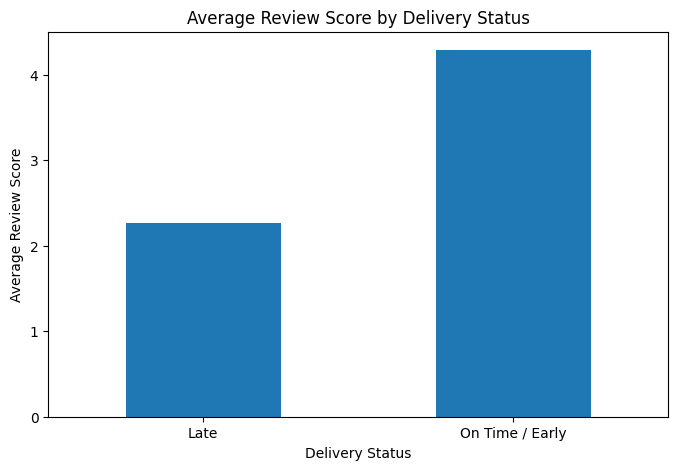

In [18]:
import matplotlib.pyplot as plt

review_impact_df.plot(
    x="delivery_status",
    y="average_review_score",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")

plt.xticks(rotation=0)

plt.show()

## Impact of Delivery Performance on Customer Satisfaction

The analysis reveals a strong relationship between delivery performance and customer review scores.

### Review Score Summary

| Delivery Status | Average Review Score | Orders |
|:-----------------|--------------------:|-------:|
| On Time / Early | 4.29 | 88,591 |
| Late | 2.27 | 6,385 |

### Key Findings

- Orders delivered on time or early receive an average review score of **4.29 out of 5**.
- Late deliveries receive an average review score of only **2.27 out of 5**.
- Late deliveries result in a decrease of approximately **2 review points**.

```text
4.29 − 2.27 = 2.02


---


## Business Interpretation

Although only 6.85% of orders are delivered late, these delays have a substantial impact on customer perception.

Customers appear willing to provide high ratings when orders arrive on time or earlier than expected.

However, delivery delays are strongly associated with negative reviews.

Lower review scores can lead to:

- Reduced customer loyalty
- Lower repeat purchase rates
- Increased customer support costs
- Negative word-of-mouth
- Damage to brand reputation

Improving delivery reliability is likely to generate meaningful improvements in customer satisfaction and retention.

## Recommendations

To improve customer satisfaction, the business should focus on reducing late deliveries.

Recommended actions include:

- Monitor carrier performance by region.
- Identify products associated with higher delivery delays.
- Create alerts for orders at risk of missing delivery estimates.
- Review warehouse processing times.
- Optimize inventory allocation across fulfillment centers.

Even small reductions in late deliveries could significantly improve average review scores and customer retention.

## Business Question

Which states experience the highest percentage of late deliveries?

Identifying geographic patterns in delivery performance helps the business prioritize operational improvements and optimize logistics networks.

## Why Analyze Late Deliveries by State?

Delivery performance can vary significantly across regions due to factors such as:

- Distance from fulfillment centers
- Carrier coverage and reliability
- Regional infrastructure limitations
- Inventory availability
- Seasonal demand fluctuations

Understanding which states experience more delays allows the business to:

- Improve carrier selection
- Optimize inventory placement
- Adjust delivery estimates
- Prioritize operational improvements

Geographic insights help transform delivery performance into actionable business decisions.

In [21]:
# Merge delivery metrics with customer location data.

delivery_state_df = valid_delivery_metrics_df.merge(
    customers_df[
        [
            "customer_id",
            "customer_state"
        ]
    ],
    on="customer_id",
    how="left"
)

# Review the merged dataset.

delivery_state_df[
    [
        "customer_state",
        "delivery_status",
        "delivery_delay_days"
    ]
].head()

,customer_state,delivery_status,delivery_delay_days
0,SP,On Time / Early,-8
1,BA,On Time / Early,-6
2,GO,On Time / Early,-18
3,RN,On Time / Early,-13
4,SP,On Time / Early,-10


In [22]:
# Calculate delivery performance by state.

state_delivery_df = (
    delivery_state_df
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "count"),
        late_orders=("delivery_status", lambda x: (x == "Late").sum())
    )
    .reset_index()
)

# Calculate the percentage of late deliveries.

state_delivery_df["late_delivery_pct"] = (
    state_delivery_df["late_orders"]
    / state_delivery_df["total_orders"]
    * 100
).round(2)

# Sort states by highest late-delivery rate.

state_delivery_df = state_delivery_df.sort_values(
    by="late_delivery_pct",
    ascending=False
)

state_delivery_df.head(10)

,customer_state,total_orders,late_orders,late_delivery_pct
1,AL,393,83,21.12
9,MA,704,125,17.76
24,SE,333,51,15.32
16,PI,469,66,14.07
5,CE,1259,176,13.98
21,RR,40,5,12.50
18,RJ,12213,1492,12.22
4,BA,3210,391,12.18
13,PA,936,104,11.11
7,ES,1968,213,10.82


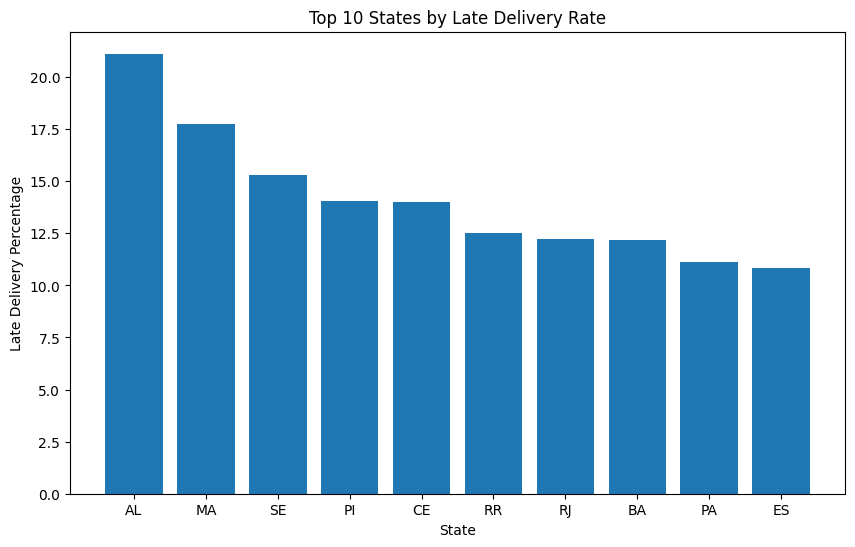

In [23]:
import matplotlib.pyplot as plt

top_states_df = state_delivery_df.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_states_df["customer_state"],
    top_states_df["late_delivery_pct"]
)

plt.title("Top 10 States by Late Delivery Rate")
plt.xlabel("State")
plt.ylabel("Late Delivery Percentage")

plt.show()

## Late Deliveries by State

Delivery performance varies significantly across states.

### Top States by Late Delivery Rate

| State | Total Orders | Late Delivery Rate |
|:-------|-------------:|-------------------:|
| AL | 393 | 21.12% |
| MA | 704 | 17.76% |
| SE | 333 | 15.32% |
| PI | 469 | 14.07% |
| CE | 1,259 | 13.98% |
| RR | 40 | 12.50% |
| RJ | 12,213 | 12.22% |
| BA | 3,210 | 12.18% |
| PA | 936 | 11.11% |
| ES | 1,968 | 10.82% |

### Key Findings

- Late-delivery rates vary considerably across regions.
- Some states experience late-delivery rates that are more than three times the overall average of 6.85%.
- States with low order volumes should be interpreted carefully because a small number of late orders can significantly affect percentages.

Among high-volume states, **Rio de Janeiro (RJ)** and **Bahia (BA)** stand out as important areas for improvement due to both high order volume and high late-delivery rates.

## Business Interpretation

Delivery challenges are not evenly distributed across the country.

Regional differences may be influenced by:

- Distance from fulfillment centers
- Carrier availability and reliability
- Transportation infrastructure
- Inventory placement
- Local demand patterns

High-volume states with above-average late-delivery rates represent the largest opportunity for operational improvement.

Improving delivery performance in these regions could significantly increase customer satisfaction and reduce negative reviews.
## Recommendations

To reduce late deliveries, the business should:

- Analyze carrier performance by state.
- Review warehouse coverage and inventory allocation.
- Consider regional delivery estimates instead of a single national estimate.
- Investigate infrastructure or logistics challenges in high-delay regions.
- Monitor late-delivery trends over time.

Prioritize operational improvements in states with both high order volume and high late-delivery rates, such as Rio de Janeiro and Bahia.

## Business Question

Are certain product categories more likely to be delivered late?

Identifying product categories with higher late-delivery rates helps the business improve inventory planning, packaging processes, and logistics operations.
## Why Analyze Delivery Performance by Product Category?

Not all products have the same fulfillment requirements.

Some categories may experience more delays due to factors such as:

- Large or bulky dimensions
- Fragile packaging requirements
- Supplier constraints
- Inventory shortages
- Specialized shipping needs

Understanding which product categories are associated with delivery delays helps the business:

- Improve inventory allocation
- Optimize packaging processes
- Negotiate with suppliers
- Select appropriate carriers
- Set realistic delivery expectations

In [30]:
# Merge delivery metrics with order items.

delivery_products_df = valid_delivery_metrics_df.merge(
    order_items_df[
        [
            "order_id",
            "product_id"
        ]
    ],
    on="order_id",
    how="inner"
)

# Merge with product information.

delivery_products_df = delivery_products_df.merge(
    products_df[
        [
            "product_id",
            "product_category_name"
        ]
    ],
    on="product_id",
    how="left"
)

# Merge with category translations.

delivery_products_df = delivery_products_df.merge(
    product_category_name_translation_df,
    on="product_category_name",
    how="left"
)

In [31]:
# Prevent counting the same order multiple times
# within the same category.

delivery_products_df = delivery_products_df.drop_duplicates(
    subset=[
        "order_id",
        "product_category_name_english"
    ]
)

In [32]:
category_delivery_df = (
    delivery_products_df
    .groupby("product_category_name_english")
    .agg(
        total_orders=("order_id", "nunique"),
        late_orders=(
            "delivery_status",
            lambda x: (x == "Late").sum()
        )
    )
    .reset_index()
)

category_delivery_df["late_delivery_pct"] = (
    category_delivery_df["late_orders"]
    / category_delivery_df["total_orders"]
    * 100
).round(2)

category_delivery_df = (
    category_delivery_df[
        category_delivery_df["total_orders"] >= 100
    ]
    .sort_values(
        by="late_delivery_pct",
        ascending=False
    )
)

category_delivery_df.head(10)

,product_category_name_english,total_orders,late_orders,late_delivery_pct
4,audio,344,41,11.92
47,home_confort,385,37,9.61
33,fashion_underwear_beach,117,11,9.40
10,books_technical,248,21,8.47
6,baby,2771,225,8.12
57,office_furniture,1248,101,8.09
12,christmas_supplies,124,10,8.06
26,electronics,2487,192,7.72
43,health_beauty,8497,647,7.61
56,musical_instruments,605,46,7.60


In [28]:
# Calculate delivery performance by product category.

category_delivery_df = (
    delivery_products_df
    .groupby("product_category_name")
    .agg(
        total_orders=("order_id", "nunique"),
        late_orders=(
            "delivery_status",
            lambda x: (x == "Late").sum()
        )
    )
    .reset_index()
)

# Calculate late-delivery percentage.

category_delivery_df["late_delivery_pct"] = (
    category_delivery_df["late_orders"]
    / category_delivery_df["total_orders"]
    * 100
).round(2)

# Remove categories with low order volume.

category_delivery_df = (
    category_delivery_df[
        category_delivery_df["total_orders"] >= 100
    ]
    .sort_values(
        by="late_delivery_pct",
        ascending=False
    )
)

category_delivery_df.head(10)

,product_category_name,total_orders,late_orders,late_delivery_pct
7,audio,344,42,12.21
6,artigos_de_natal,124,15,12.10
55,moveis_escritorio,1248,133,10.66
14,casa_conforto,385,40,10.39
39,fashion_underwear_e_moda_praia,117,12,10.26
23,construcao_ferramentas_iluminacao,238,22,9.24
54,moveis_decoracao,6227,572,9.19
57,moveis_sala,411,35,8.52
49,livros_tecnicos,248,21,8.47
13,cama_mesa_banho,9130,767,8.40


## Late Deliveries by Product Category

Delivery performance varies across product categories.

Some products may require special handling, larger packaging, or more complex logistics processes, increasing the likelihood of delays.

### Top Product Categories by Late Delivery Rate

| Product Category | Total Orders | Late Delivery Rate |
|:------------------|-------------:|-------------------:|
| Audio | 344 | 11.92% |
| Home Comfort | 385 | 9.61% |
| Fashion Underwear & Beach | 117 | 9.40% |
| Technical Books | 248 | 8.47% |
| Baby | 2,771 | 8.12% |
| Office Furniture | 1,248 | 8.09% |
| Christmas Supplies | 124 | 8.06% |
| Electronics | 2,487 | 7.72% |
| Health & Beauty | 8,497 | 7.61% |
| Musical Instruments | 605 | 7.60% |

### Key Findings

- Several categories exceed the overall late-delivery rate of **6.85%**.
- Categories such as **Audio**, **Home Comfort**, and **Office Furniture** experience higher-than-average delays.
- High-volume categories like **Baby**, **Electronics**, and **Health & Beauty** deserve special attention because small improvements can affect a large number of customers.

Although Audio products have the highest late-delivery rate, categories with larger order volumes may have a greater business impact.
## Business Interpretation

Product characteristics can significantly influence delivery performance.

Potential causes of higher late-delivery rates include:

- Large or bulky items requiring specialized shipping
- Fragile products requiring additional packaging
- Supplier lead-time variability
- Inventory shortages
- Seasonal demand spikes

For example:

- Office furniture may require special handling and transportation.
- Electronics may face supplier or inventory constraints.
- Baby products can experience demand fluctuations and stock shortages.

Understanding category-specific challenges enables the business to create targeted operational improvements.

## Recommendations

To reduce late deliveries by product category, the business should:

- Monitor inventory levels for high-risk categories.
- Evaluate supplier performance and lead times.
- Use specialized carriers for bulky or fragile products.
- Review packaging and warehouse processes.
- Adjust estimated delivery dates by product category.

Prioritize categories that combine:

1. High late-delivery rates
2. High order volume

These categories offer the greatest opportunity to improve customer satisfaction.

# Executive Summary

## Project Objective

The objective of this analysis was to evaluate the Olist order fulfillment process, identify operational bottlenecks, and understand how delivery performance impacts customer satisfaction.

The analysis examined the complete customer journey from order placement to final delivery.

Key areas of focus included:

- Order funnel conversion
- Fulfillment timelines
- Delivery reliability
- Customer satisfaction
- Geographic delivery performance
- Product category performance

## Key Findings

### 1. Strong Overall Funnel Performance

- Total orders analyzed: **99,441**
- Successfully delivered orders: **96,476**
- Purchase-to-delivery conversion rate: **97.02%**

The largest drop-off occurs between the approval and shipment stages.

### 2. Delivery Is the Longest Stage

Average fulfillment times:

| Metric | Average Days |
|:--------|--------------:|
| Approval Time | 0.24 |
| Shipping Time | 2.35 |
| Delivery Time | 8.91 |
| Total Fulfillment Time | 12.15 |

The delivery stage accounts for approximately **73%** of the total fulfillment process.

### 3. Delivery Estimates Are Conservative

- Average delivery delay: **-11.83 days**
- Orders are delivered approximately **12 days earlier** than promised.
- On-time or early deliveries: **93.15%**
- Late deliveries: **6.85%**

Overall, delivery estimates appear reliable and conservative.

### 4. Late Deliveries Significantly Reduce Customer Satisfaction

| Delivery Status | Average Review Score |
|:-----------------|--------------------:|
| On Time / Early | 4.29 |
| Late | 2.27 |

Late deliveries reduce customer review scores by approximately **2 points**.

### 5. Geographic Differences Exist

States with the highest late-delivery rates include:

- Alagoas (AL)
- Maranhão (MA)
- Sergipe (SE)
- Ceará (CE)
- Rio de Janeiro (RJ)

High-volume states with elevated late-delivery rates represent the largest opportunity for improvement.

### 6. Product Categories Influence Delivery Performance

Categories with the highest late-delivery rates include:

- Audio
- Home Comfort
- Baby
- Office Furniture
- Electronics

High-volume categories should be prioritized due to their greater customer impact.

## Strategic Recommendations

Based on the analysis, the following actions are recommended:

### 1. Improve Approval-to-Shipment Efficiency

Focus on reducing delays between payment approval and shipment by:

- Optimizing warehouse operations
- Improving inventory visibility
- Monitoring order processing times

### 2. Optimize Last-Mile Delivery

Since delivery accounts for most of the fulfillment time:

- Evaluate carrier performance
- Improve route optimization
- Strengthen regional logistics networks

### 3. Implement Regional Delivery Strategies

Develop state-specific delivery targets and estimates.

Prioritize operational improvements in high-volume states with above-average late-delivery rates.

### 4. Create Category-Specific Delivery Plans

Adjust fulfillment processes for categories with elevated delay rates.

Examples include:

- Office Furniture
- Electronics
- Baby Products

### 5. Monitor Customer Experience Metrics

Establish dashboards to track:

- Late-delivery rates
- Delivery times
- Review scores
- Regional performance
- Product category performance

Improving delivery reliability is likely to increase customer satisfaction, retention, and long-term customer value.

### One-Sentence Summary

The analysis identified that while Olist achieves a strong 97% purchase-to-delivery conversion rate and delivers 93% of orders on time or early, late deliveries significantly reduce customer satisfaction, highlighting opportunities to optimize logistics performance by region and product category.